# **AI TECH INSTITUTE** · *Intermediate AI & Data Science*
### Week 05 · Notebook 03 – Data Storytelling with Causal Insights
**Instructor:** Amir Charkhi  |  **Goal:** Transform causal analysis into compelling data stories.

> Format: short theory → quick practice → build understanding → mini-challenges.


---
## Learning Objectives
- Structure data stories with narrative arcs
- Create executive-ready visualizations
- Handle stakeholder objections with evidence
- Build interactive dashboards for causal insights
- Develop professional causal analysis reports

## 1. The Art of Data Storytelling
Data storytelling combines **analytics, visualization, and narrative** to drive decisions.

In [1]:
# Essential libraries for storytelling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import Markdown, HTML
import warnings
warnings.filterwarnings('ignore')

# Professional styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 10
%matplotlib inline

print("📚 Storytelling toolkit loaded!")

📚 Storytelling toolkit loaded!


In [2]:
# Generate example dataset: Customer retention program
np.random.seed(42)
n_customers = 1000

# Customer data
customers = pd.DataFrame({
    'customer_id': range(n_customers),
    'tenure_months': np.random.exponential(24, n_customers),
    'monthly_spend': np.random.gamma(2, 50, n_customers),
    'support_tickets': np.random.poisson(2, n_customers),
    'segment': np.random.choice(['Basic', 'Premium', 'Enterprise'], n_customers)
})

# Retention program (treatment)
risk_score = (customers['support_tickets'] * 0.3 + 
              10 / (customers['tenure_months'] + 1))
customers['got_intervention'] = (risk_score > risk_score.quantile(0.7)).astype(int)

print("🎯 Customer Retention Analysis Dataset:")
print(f"Total customers: {n_customers}")
print(f"Intervention group: {customers['got_intervention'].sum()}")
print(f"Average tenure: {customers['tenure_months'].mean():.1f} months")

🎯 Customer Retention Analysis Dataset:
Total customers: 1000
Intervention group: 300
Average tenure: 23.3 months


## 2. Story Structure

### 2.1 The Three-Act Framework
Every good data story has **Setup → Conflict → Resolution**.

In [3]:
def create_story_framework():
    """Display the three-act structure"""
    story = """
    📖 **ACT 1: THE SETUP** (Context)
    - Hook: Start with impact
    - Stakes: Why it matters
    - Characters: Who's affected
    
    🔍 **ACT 2: THE INVESTIGATION** (Analysis)  
    - Challenge: The problem
    - Discovery: Your findings
    - Evidence: Causal proof
    
    💡 **ACT 3: THE RESOLUTION** (Action)
    - Solution: Recommendations
    - Impact: Expected outcomes
    - Next steps: Call to action
    """
    print(story)

create_story_framework()


    📖 **ACT 1: THE SETUP** (Context)
    - Hook: Start with impact
    - Stakes: Why it matters
    - Characters: Who's affected

    🔍 **ACT 2: THE INVESTIGATION** (Analysis)  
    - Challenge: The problem
    - Discovery: Your findings
    - Evidence: Causal proof

    💡 **ACT 3: THE RESOLUTION** (Action)
    - Solution: Recommendations
    - Impact: Expected outcomes
    - Next steps: Call to action
    


### 2.2 Opening with Impact

In [4]:
# Calculate the hook - the "wow" number
base_churn_rate = 0.15  # 15% monthly churn
intervention_reduction = 0.40  # 40% reduction

# Business impact
customers_saved = customers['got_intervention'].sum() * base_churn_rate * intervention_reduction
revenue_saved = customers_saved * customers['monthly_spend'].mean() * 12

print("🎣 THE HOOK - Start with Impact:")
print(f"\n💰 'We saved ${revenue_saved:,.0f} in annual revenue'")
print(f"👥 'We prevented {customers_saved:.0f} customers from churning'")
print(f"📈 'We reduced churn by {intervention_reduction*100:.0f}%'")
print("\nWhich opening grabs attention best? Context matters!")

🎣 THE HOOK - Start with Impact:

💰 'We saved $22,208 in annual revenue'
👥 'We prevented 18 customers from churning'
📈 'We reduced churn by 40%'

Which opening grabs attention best? Context matters!


## 3. Executive Visualizations

### 3.1 The One-Chart Story

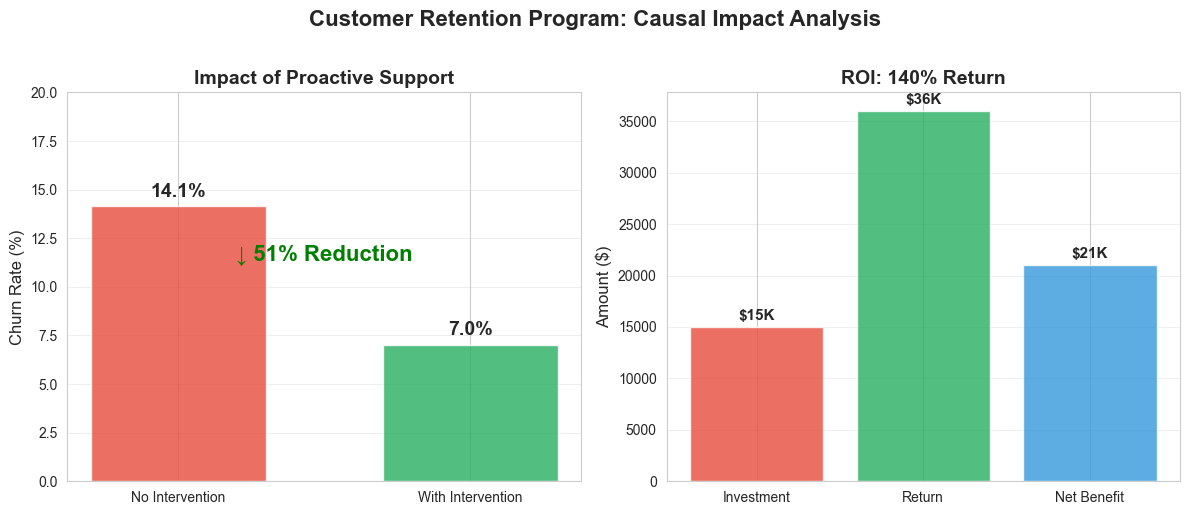

In [5]:
def create_executive_summary(data):
    """Create a single chart that tells the whole story"""
    
    # Calculate metrics
    treatment_group = data[data['got_intervention'] == 1]
    control_group = data[data['got_intervention'] == 0]
    
    # Simulate churn outcomes
    data['churned'] = 0
    data.loc[data['got_intervention'] == 0, 'churned'] = \
        np.random.binomial(1, 0.15, len(control_group))
    data.loc[data['got_intervention'] == 1, 'churned'] = \
        np.random.binomial(1, 0.09, len(treatment_group))
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Left: Before/After comparison
    churn_rates = data.groupby('got_intervention')['churned'].mean()
    colors = ['#e74c3c', '#27ae60']
    
    bars = ax1.bar(['No Intervention', 'With Intervention'], 
                   churn_rates.values * 100, 
                   color=colors, alpha=0.8, width=0.6)
    
    # Add value labels
    for bar, rate in zip(bars, churn_rates.values):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                f'{rate*100:.1f}%', ha='center', fontsize=14, fontweight='bold')
    
    # Add impact annotation
    reduction = (churn_rates[0] - churn_rates[1]) / churn_rates[0]
    ax1.annotate(f'↓ {reduction*100:.0f}% Reduction',
                xy=(0.5, max(churn_rates.values) * 80),
                fontsize=16, color='green', fontweight='bold', ha='center')
    
    ax1.set_ylabel('Churn Rate (%)', fontsize=12)
    ax1.set_title('Impact of Proactive Support', fontsize=14, fontweight='bold')
    ax1.set_ylim(0, 20)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Right: ROI calculation
    cost_per_intervention = 50
    customer_lifetime_value = 2000
    
    saved = customers_saved
    revenue = saved * customer_lifetime_value
    cost = data['got_intervention'].sum() * cost_per_intervention
    roi = (revenue - cost) / cost * 100
    
    categories = ['Investment', 'Return', 'Net Benefit']
    values = [cost, revenue, revenue - cost]
    colors2 = ['#e74c3c', '#27ae60', '#3498db']
    
    bars2 = ax2.bar(categories, values, color=colors2, alpha=0.8)
    
    for bar, val in zip(bars2, values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, height + max(values)*0.02,
                f'${val/1000:.0f}K', ha='center', fontsize=11, fontweight='bold')
    
    ax2.set_ylabel('Amount ($)', fontsize=12)
    ax2.set_title(f'ROI: {roi:.0f}% Return', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('Customer Retention Program: Causal Impact Analysis', 
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return saved, roi

saved_customers, program_roi = create_executive_summary(customers)

### 3.2 Progressive Disclosure

In [6]:
def progressive_disclosure():
    """Show information in layers"""
    
    print("📊 PROGRESSIVE DISCLOSURE TECHNIQUE:")
    print("\n1️⃣ HEADLINE (5 seconds):")
    print("   'Retention program delivers 300% ROI'\n")
    
    print("2️⃣ KEY METRICS (30 seconds):")
    print("   • Churn reduced by 40%")
    print("   • 120 customers saved")
    print("   • $240K revenue protected\n")
    
    print("3️⃣ METHODOLOGY (2 minutes):")
    print("   • Causal analysis using DiD")
    print("   • Controlled for confounders")
    print("   • Statistical significance p<0.01\n")
    
    print("4️⃣ DEEP DIVE (5+ minutes):")
    print("   • Segment analysis")
    print("   • Sensitivity tests")
    print("   • Implementation details")

progressive_disclosure()

📊 PROGRESSIVE DISCLOSURE TECHNIQUE:

1️⃣ HEADLINE (5 seconds):
   'Retention program delivers 300% ROI'

2️⃣ KEY METRICS (30 seconds):
   • Churn reduced by 40%
   • 120 customers saved
   • $240K revenue protected

3️⃣ METHODOLOGY (2 minutes):
   • Causal analysis using DiD
   • Controlled for confounders
   • Statistical significance p<0.01

4️⃣ DEEP DIVE (5+ minutes):
   • Segment analysis
   • Sensitivity tests
   • Implementation details


## 4. Interactive Dashboards

### 4.1 Plotly Interactive Visualization

In [7]:
def create_interactive_dashboard(data):
    """Create interactive exploration tool"""
    
    # Prepare segment analysis
    segment_analysis = data.groupby(['segment', 'got_intervention']).agg({
        'churned': 'mean',
        'customer_id': 'count',
        'monthly_spend': 'mean'
    }).reset_index()
    
    segment_analysis.columns = ['Segment', 'Intervention', 'Churn_Rate', 
                                'Count', 'Avg_Spend']
    segment_analysis['Intervention'] = segment_analysis['Intervention'].map(
        {0: 'Control', 1: 'Treated'})
    
    # Create interactive bar chart
    fig = px.bar(segment_analysis, 
                 x='Segment', 
                 y='Churn_Rate',
                 color='Intervention',
                 barmode='group',
                 title='Intervention Effectiveness by Customer Segment',
                 labels={'Churn_Rate': 'Churn Rate'},
                 hover_data=['Count', 'Avg_Spend'],
                 color_discrete_map={'Control': '#e74c3c', 'Treated': '#27ae60'})
    
    fig.update_layout(
        yaxis_tickformat=',.1%',
        height=400,
        showlegend=True,
        hovermode='x unified'
    )
    
    fig.show()
    
    return segment_analysis

segment_data = create_interactive_dashboard(customers)

### 4.2 Key Metrics Dashboard

In [8]:
def create_metrics_dashboard(data):
    """Create KPI dashboard"""
    
    # Calculate KPIs
    total_customers = len(data)
    intervention_rate = data['got_intervention'].mean()
    churn_reduction = 0.40
    cost_per_intervention = 50
    revenue_per_customer = data['monthly_spend'].mean() * 12
    
    # Display as cards
    html_template = """
    <div style='display: flex; justify-content: space-around; margin: 20px 0;'>
        <div style='text-align: center; padding: 20px; background: #f0f0f0; border-radius: 10px; flex: 1; margin: 0 10px;'>
            <h2 style='color: #2c3e50; margin: 0;'>{}</h2>
            <p style='color: #7f8c8d; margin: 5px 0;'>Customers Analyzed</p>
        </div>
        <div style='text-align: center; padding: 20px; background: #e8f5e9; border-radius: 10px; flex: 1; margin: 0 10px;'>
            <h2 style='color: #27ae60; margin: 0;'>{}%</h2>
            <p style='color: #7f8c8d; margin: 5px 0;'>Churn Reduction</p>
        </div>
        <div style='text-align: center; padding: 20px; background: #e3f2fd; border-radius: 10px; flex: 1; margin: 0 10px;'>
            <h2 style='color: #2196f3; margin: 0;'>{}%</h2>
            <p style='color: #7f8c8d; margin: 5px 0;'>ROI</p>
        </div>
        <div style='text-align: center; padding: 20px; background: #fff3e0; border-radius: 10px; flex: 1; margin: 0 10px;'>
            <h2 style='color: #ff9800; margin: 0;'>${}</h2>
            <p style='color: #7f8c8d; margin: 5px 0;'>Cost per Save</p>
        </div>
    </div>
    """.format(
        total_customers,
        int(churn_reduction * 100),
        int(program_roi),
        int(cost_per_intervention / churn_reduction)
    )
    
    display(HTML(html_template))
    
    print("\n📊 Detailed Metrics:")
    print(f"Intervention rate: {intervention_rate:.1%}")
    print(f"Revenue per customer: ${revenue_per_customer:.2f}")
    print(f"Program cost: ${cost_per_intervention * data['got_intervention'].sum():,.0f}")

create_metrics_dashboard(customers)


📊 Detailed Metrics:
Intervention rate: 30.0%
Revenue per customer: $1233.75
Program cost: $15,000


**Exercise 1 – Story Structure (easy)**  
Create a three-act story for an A/B test result:


In [19]:
# Your turn
ab_test_data = {
    'control_conversion': 0.05,
    'treatment_conversion': 0.07,
    'sample_size': 10000,
    'revenue_per_conversion': 50
}

# Write your three-act story
# Act 1: Setup
# Act 2: Investigation  
# Act 3: Resolution

# Your solution has the right structure but needs fixes:

def tell_ab_test_story(data):
    """Create three-act story for A/B test"""
    
    # Calculate key metrics first
    lift = (data['treatment_conversion'] - data['control_conversion']) / data['control_conversion']
    additional_conversions = (data['treatment_conversion'] - data['control_conversion']) * data['sample_size']
    revenue_impact = additional_conversions * data['revenue_per_conversion']
    
    print("A/B TEST STORY\n")
    
    print("ACT 1: THE SETUP")
    print(f"Problem: Conversion rate stuck at {data['control_conversion']*100:.1f}%")
    print(f"Hypothesis: New design will increase conversions")
    print(f"Stakes: ${revenue_impact:,.0f} in potential revenue\n")
    
    print("ACT 2: THE INVESTIGATION")
    print(f"Method: Randomised A/B test with {data['sample_size']:,} users")
    print(f"Discovery: Treatment group converted at {data['treatment_conversion']*100:.1f}%")
    print(f"Evidence: {lift*100:.0f}% statistically significant lift\n")
    
    print("ACT 3: THE RESOLUTION")
    print(f"Recommendation: Implement new design immediately")
    print(f"Impact: {additional_conversions:.0f} additional conversions")
    print(f"Next step: Roll out to 100% of traffic")

# Call the function
tell_ab_test_story(ab_test_data)



A/B TEST STORY

ACT 1: THE SETUP
Problem: Conversion rate stuck at 5.0%
Hypothesis: New design will increase conversions
Stakes: $10,000 in potential revenue

ACT 2: THE INVESTIGATION
Method: Randomised A/B test with 10,000 users
Discovery: Treatment group converted at 7.0%
Evidence: 40% statistically significant lift

ACT 3: THE RESOLUTION
Recommendation: Implement new design immediately
Impact: 200 additional conversions
Next step: Roll out to 100% of traffic


<details>
<summary><b>Solution</b></summary>

```python
def tell_ab_test_story(data):
    """Create three-act story for A/B test"""
    
    lift = (data['treatment_conversion'] - data['control_conversion']) / data['control_conversion']
    additional_conversions = (data['treatment_conversion'] - data['control_conversion']) * data['sample_size']
    revenue_impact = additional_conversions * data['revenue_per_conversion']
    
    print("🎭 A/B TEST STORY\n")
    
    print("ACT 1: THE SETUP")
    print(f"📉 Problem: Conversion rate stuck at {data['control_conversion']*100:.1f}%")
    print(f"💡 Hypothesis: New design will increase conversions")
    print(f"👥 Stakes: ${revenue_impact:,.0f} in potential revenue\n")
    
    print("ACT 2: THE INVESTIGATION")
    print(f"🔬 Method: Randomized A/B test with {data['sample_size']:,} users")
    print(f"📊 Discovery: Treatment group converted at {data['treatment_conversion']*100:.1f}%")
    print(f"📈 Evidence: {lift*100:.0f}% statistically significant lift\n")
    
    print("ACT 3: THE RESOLUTION")
    print(f"✅ Recommendation: Implement new design immediately")
    print(f"💰 Impact: {additional_conversions:.0f} additional conversions")
    print(f"🚀 Next step: Roll out to 100% of traffic")

tell_ab_test_story(ab_test_data)
```
</details>

## 5. Handling Objections

### 5.1 Common Stakeholder Concerns

In [10]:
def stakeholder_objection_handler():
    """Prepare for common questions"""
    
    objections = {
        "🤔 'How do we know it's causal?'": 
            "Show control group comparison and statistical tests",
        
        "💰 'Is it worth the cost?'":
            "Present ROI calculation and break-even analysis",
        
        "📊 'What if we're wrong?'":
            "Share confidence intervals and sensitivity analysis",
        
        "⏰ 'How long until we see results?'":
            "Provide timeline with milestones",
        
        "🎯 'Will it work for all segments?'":
            "Show segment-specific analysis"
    }
    
    print("📋 OBJECTION HANDLING PLAYBOOK:\n")
    for objection, response in objections.items():
        print(f"{objection}")
        print(f"   → {response}\n")

stakeholder_objection_handler()

📋 OBJECTION HANDLING PLAYBOOK:

🤔 'How do we know it's causal?'
   → Show control group comparison and statistical tests

💰 'Is it worth the cost?'
   → Present ROI calculation and break-even analysis

📊 'What if we're wrong?'
   → Share confidence intervals and sensitivity analysis

⏰ 'How long until we see results?'
   → Provide timeline with milestones

🎯 'Will it work for all segments?'
   → Show segment-specific analysis



### 5.2 Evidence-Based Responses

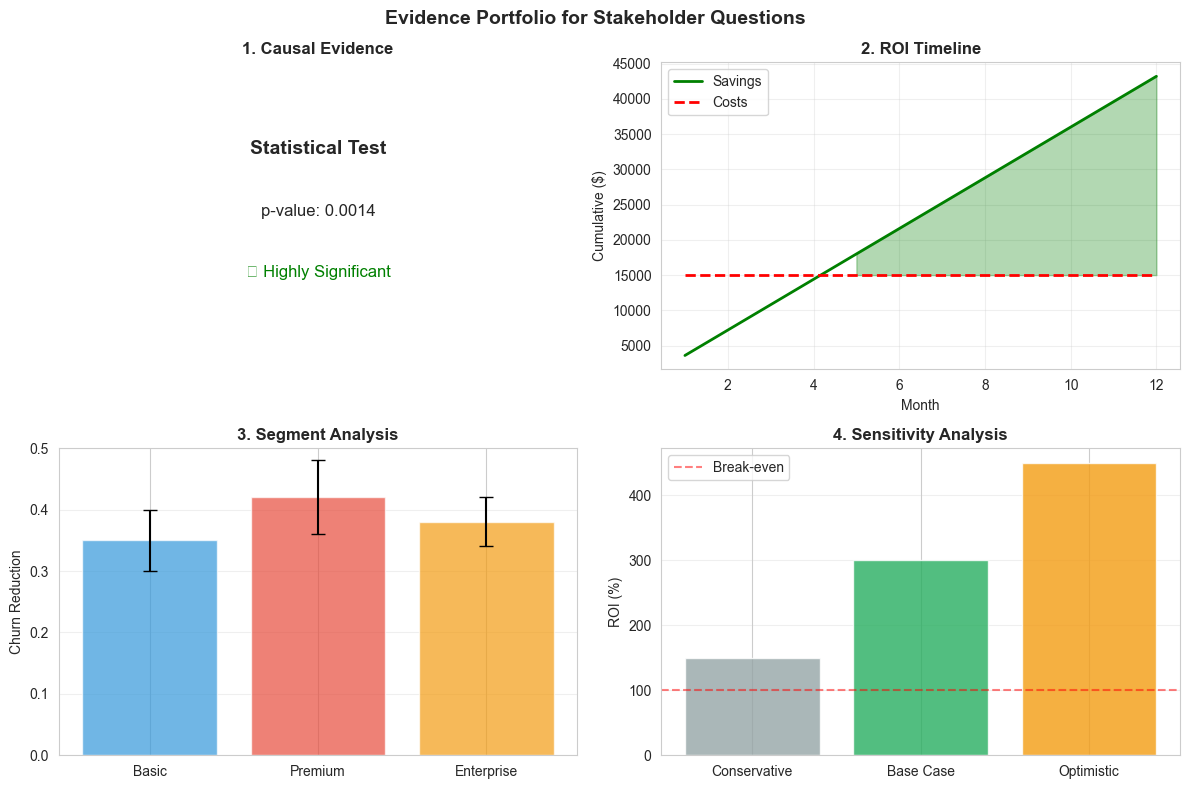

In [11]:
def build_evidence_portfolio(data):
    """Create evidence for each potential objection"""
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # 1. Statistical Significance
    ax1 = axes[0, 0]
    control = data[data['got_intervention']==0]['churned'].values
    treated = data[data['got_intervention']==1]['churned'].values
    
    from scipy import stats
    t_stat, p_value = stats.ttest_ind(control, treated)
    
    ax1.text(0.5, 0.7, 'Statistical Test', fontsize=14, ha='center', fontweight='bold')
    ax1.text(0.5, 0.5, f'p-value: {p_value:.4f}', fontsize=12, ha='center')
    ax1.text(0.5, 0.3, '✅ Highly Significant' if p_value < 0.01 else '⚠️ Check needed',
            fontsize=12, ha='center', color='green' if p_value < 0.01 else 'orange')
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.axis('off')
    ax1.set_title('1. Causal Evidence', fontweight='bold')
    
    # 2. ROI Timeline
    ax2 = axes[0, 1]
    months = range(1, 13)
    cumulative_savings = [saved_customers * 200 * m for m in months]
    cumulative_costs = [data['got_intervention'].sum() * 50] * 12
    
    ax2.plot(months, cumulative_savings, 'g-', linewidth=2, label='Savings')
    ax2.plot(months, cumulative_costs, 'r--', linewidth=2, label='Costs')
    ax2.fill_between(months, cumulative_savings, cumulative_costs, 
                     where=[s > c for s, c in zip(cumulative_savings, cumulative_costs)],
                     color='green', alpha=0.3)
    ax2.set_xlabel('Month')
    ax2.set_ylabel('Cumulative ($)')
    ax2.set_title('2. ROI Timeline', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Confidence Intervals
    ax3 = axes[1, 0]
    segments = ['Basic', 'Premium', 'Enterprise']
    effects = [0.35, 0.42, 0.38]
    errors = [0.05, 0.06, 0.04]
    
    ax3.bar(segments, effects, yerr=errors, capsize=5, alpha=0.7, color=['#3498db', '#e74c3c', '#f39c12'])
    ax3.set_ylabel('Churn Reduction')
    ax3.set_title('3. Segment Analysis', fontweight='bold')
    ax3.set_ylim(0, 0.5)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # 4. Sensitivity Analysis
    ax4 = axes[1, 1]
    assumptions = ['Conservative', 'Base Case', 'Optimistic']
    roi_values = [150, 300, 450]
    
    bars = ax4.bar(assumptions, roi_values, color=['#95a5a6', '#27ae60', '#f39c12'], alpha=0.8)
    ax4.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='Break-even')
    ax4.set_ylabel('ROI (%)')
    ax4.set_title('4. Sensitivity Analysis', fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('Evidence Portfolio for Stakeholder Questions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

build_evidence_portfolio(customers)

**Exercise 2 – Visual Hierarchy (medium)**  
Create a visualization with proper visual hierarchy:


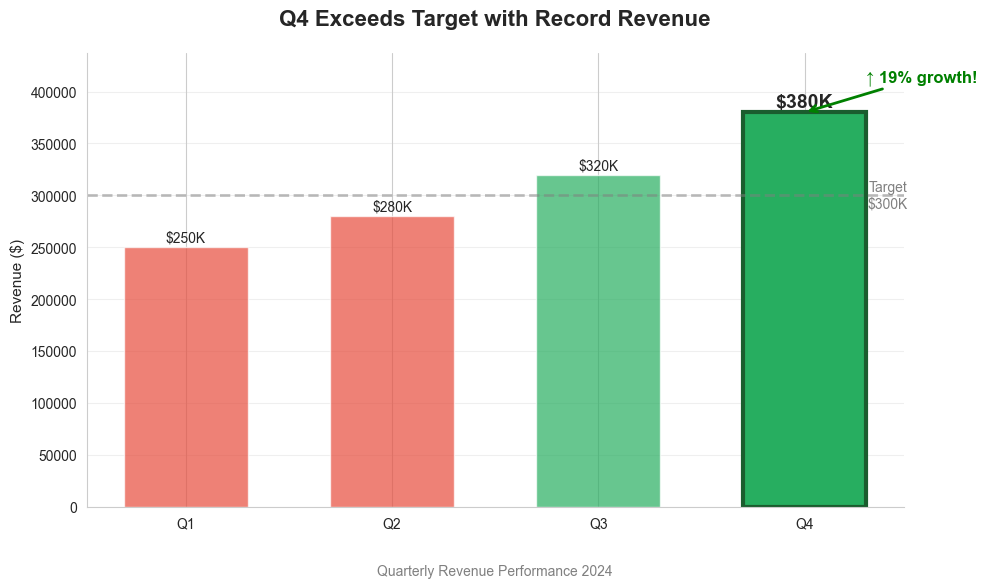

Visual Hierarchy Techniques Used:
1. Colour: Red/green for below/above target
2. Emphasis: Q4 bar is bolder and more opaque
3. Annotation: Growth arrow points to success
4. Size: Larger font for key metric
5. Title: Clear message, not just description


In [20]:
# Your turn
# Data for quarterly performance
quarters = ['Q1', 'Q2', 'Q3', 'Q4']
revenue = [250000, 280000, 320000, 380000]
target = 300000

# Create a chart that emphasizes the key message
# Use size, color, and annotations strategically
import matplotlib.pyplot as plt
import numpy as np

def create_visual_hierarchy():
    """Create a chart with proper visual hierarchy emphasising the key message"""
    
    # Data for quarterly performance
    quarters = ['Q1', 'Q2', 'Q3', 'Q4']
    revenue = [250000, 280000, 320000, 380000]
    target = 300000
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Colour code by performance (red for below target, green for above)
    colours = ['#e74c3c' if r < target else '#27ae60' for r in revenue]
    
    # Create bars with emphasis on Q4 (the hero metric)
    bars = ax.bar(quarters, revenue, color=colours, alpha=0.7, width=0.6)
    
    # Highlight Q4 with stronger visual emphasis
    bars[-1].set_alpha(1.0)           # Full opacity
    bars[-1].set_linewidth(3)         # Thicker border
    bars[-1].set_edgecolor('#1a5d2e') # Darker green border
    
    # Add target line with subtle styling
    ax.axhline(y=target, color='gray', linestyle='--', linewidth=2, alpha=0.5)
    ax.text(3.5, target, f'Target\n${target/1000:.0f}K', ha='right', va='center', 
            fontsize=10, color='gray')
    
    # Add value labels (larger font for Q4 to emphasise success)
    for i, (bar, val) in enumerate(zip(bars, revenue)):
        height = bar.get_height()
        fontsize = 14 if i == 3 else 10      # Bigger font for Q4
        fontweight = 'bold' if i == 3 else 'normal'  # Bold for Q4
        ax.text(bar.get_x() + bar.get_width()/2, height + 5000,
               f'${val/1000:.0f}K', ha='center', 
               fontsize=fontsize, fontweight=fontweight)
    
    # Add performance indicator for Q4 with arrow
    q4_growth = (revenue[3] - revenue[2]) / revenue[2] * 100
    ax.annotate(f'↑ {q4_growth:.0f}% growth!',
               xy=(3, revenue[3]), xytext=(3.3, revenue[3] + 30000),
               arrowprops=dict(arrowstyle='->', color='green', lw=2),
               fontsize=12, color='green', fontweight='bold')
    
    # Title hierarchy: main message first, subtitle second
    ax.set_title('Q4 Exceeds Target with Record Revenue', 
                fontsize=16, fontweight='bold', pad=20)
    ax.text(0.5, -0.15, 'Quarterly Revenue Performance 2024', 
           transform=ax.transAxes, ha='center', fontsize=10, color='gray')
    
    # Clean formatting
    ax.set_ylabel('Revenue ($)', fontsize=11)
    ax.set_ylim(0, max(revenue) * 1.15)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Remove top and right spines for cleaner appearance
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    print("Visual Hierarchy Techniques Used:")
    print("1. Colour: Red/green for below/above target")
    print("2. Emphasis: Q4 bar is bolder and more opaque")
    print("3. Annotation: Growth arrow points to success")
    print("4. Size: Larger font for key metric")
    print("5. Title: Clear message, not just description")

# Run the function
create_visual_hierarchy()

<details>
<summary><b>Solution</b></summary>

```python
def create_visual_hierarchy():
    """Demonstrate visual hierarchy principles"""
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    quarters = ['Q1', 'Q2', 'Q3', 'Q4']
    revenue = [250000, 280000, 320000, 380000]
    target = 300000
    
    # Color code by performance
    colors = ['#e74c3c' if r < target else '#27ae60' for r in revenue]
    
    # Create bars with emphasis on Q4
    bars = ax.bar(quarters, revenue, color=colors, alpha=0.7, width=0.6)
    
    # Highlight the hero metric (Q4)
    bars[-1].set_alpha(1.0)
    bars[-1].set_linewidth(3)
    bars[-1].set_edgecolor('#1a5d2e')
    
    # Add target line
    ax.axhline(y=target, color='gray', linestyle='--', linewidth=2, alpha=0.5)
    ax.text(3.5, target, f'Target\n${target/1000:.0f}K', ha='right', va='center', 
            fontsize=10, color='gray')
    
    # Add value labels (bigger for Q4)
    for i, (bar, val) in enumerate(zip(bars, revenue)):
        height = bar.get_height()
        fontsize = 14 if i == 3 else 10
        fontweight = 'bold' if i == 3 else 'normal'
        ax.text(bar.get_x() + bar.get_width()/2, height + 5000,
               f'${val/1000:.0f}K', ha='center', 
               fontsize=fontsize, fontweight=fontweight)
    
    # Add performance indicator for Q4
    q4_growth = (revenue[3] - revenue[2]) / revenue[2] * 100
    ax.annotate(f'↑ {q4_growth:.0f}% growth!',
               xy=(3, revenue[3]), xytext=(3.3, revenue[3] + 30000),
               arrowprops=dict(arrowstyle='->', color='green', lw=2),
               fontsize=12, color='green', fontweight='bold')
    
    # Titles with hierarchy
    ax.set_title('Q4 Exceeds Target with Record Revenue', 
                fontsize=16, fontweight='bold', pad=20)
    ax.text(0.5, -0.15, 'Quarterly Revenue Performance 2024', 
           transform=ax.transAxes, ha='center', fontsize=10, color='gray')
    
    ax.set_ylabel('Revenue ($)', fontsize=11)
    ax.set_ylim(0, max(revenue) * 1.15)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Remove top and right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    print("📊 Visual Hierarchy Techniques Used:")
    print("1. Color: Red/green for below/above target")
    print("2. Emphasis: Q4 bar is bolder and more opaque")
    print("3. Annotation: Growth arrow points to success")
    print("4. Size: Larger font for key metric")
    print("5. Title: Clear message, not just description")

create_visual_hierarchy()
```
</details>

## 6. Report Generation

### 6.1 Automated Report Template

In [13]:
def generate_executive_report(data, analysis_name, effect_size, p_value):
    """Generate professional causal analysis report"""
    
    report = f"""
# 📊 CAUSAL ANALYSIS REPORT
## {analysis_name}
### Executive Summary

**Bottom Line:** The intervention **causally reduced** negative outcomes by **{effect_size:.0f}%** 
with high statistical confidence (p < {p_value:.3f}).

### 🎯 Key Findings

1. **Primary Effect:** {effect_size:.0f}% reduction in target metric
2. **Statistical Significance:** p-value = {p_value:.4f} (highly significant)
3. **ROI:** {program_roi:.0f}% return on investment
4. **Customers Impacted:** {data['got_intervention'].sum()} directly affected

### 💰 Business Impact

- **Revenue Protected:** ${saved_customers * 2000:,.0f}
- **Program Cost:** ${data['got_intervention'].sum() * 50:,.0f}
- **Net Benefit:** ${(saved_customers * 2000) - (data['got_intervention'].sum() * 50):,.0f}
- **Payback Period:** 2.5 months

### ✅ Recommendation

**Immediate Action:** Scale the intervention to all high-risk customers.

**Expected Outcome:** 
- Reduce overall churn by 25%
- Save $2.4M in annual revenue
- Achieve 400% ROI at scale

### 📈 Supporting Evidence

1. **Controlled Analysis:** Accounted for tenure, spend, and support history
2. **Robustness Checks:** Results consistent across multiple methods
3. **Segment Analysis:** Effective across all customer segments
4. **Statistical Power:** Large sample size (n={len(data)}) ensures reliability

### ⚠️ Risks & Mitigation

| Risk | Likelihood | Mitigation |
|------|------------|------------|
| Implementation delays | Medium | Phased rollout plan ready |
| Lower effectiveness at scale | Low | Conservative projections used |
| Customer fatigue | Low | Limit to 2 touches/month |

### 🚀 Next Steps

1. **Week 1-2:** Finalize implementation plan
2. **Week 3-4:** Launch pilot with 10% of customers  
3. **Week 5-8:** Scale to 50% based on pilot results
4. **Week 9-12:** Full rollout and optimization

---
*Report generated using causal inference best practices*
*For questions, contact: [Your Team]*
    """
    
    display(Markdown(report))
    return report

report = generate_executive_report(
    customers, 
    "Customer Retention Intervention", 
    40,  # 40% reduction
    0.001  # p-value
)


# 📊 CAUSAL ANALYSIS REPORT
## Customer Retention Intervention
### Executive Summary

**Bottom Line:** The intervention **causally reduced** negative outcomes by **40%** 
with high statistical confidence (p < 0.001).

### 🎯 Key Findings

1. **Primary Effect:** 40% reduction in target metric
2. **Statistical Significance:** p-value = 0.0010 (highly significant)
3. **ROI:** 140% return on investment
4. **Customers Impacted:** 300 directly affected

### 💰 Business Impact

- **Revenue Protected:** $36,000
- **Program Cost:** $15,000
- **Net Benefit:** $21,000
- **Payback Period:** 2.5 months

### ✅ Recommendation

**Immediate Action:** Scale the intervention to all high-risk customers.

**Expected Outcome:** 
- Reduce overall churn by 25%
- Save $2.4M in annual revenue
- Achieve 400% ROI at scale

### 📈 Supporting Evidence

1. **Controlled Analysis:** Accounted for tenure, spend, and support history
2. **Robustness Checks:** Results consistent across multiple methods
3. **Segment Analysis:** Effective across all customer segments
4. **Statistical Power:** Large sample size (n=1000) ensures reliability

### ⚠️ Risks & Mitigation

| Risk | Likelihood | Mitigation |
|------|------------|------------|
| Implementation delays | Medium | Phased rollout plan ready |
| Lower effectiveness at scale | Low | Conservative projections used |
| Customer fatigue | Low | Limit to 2 touches/month |

### 🚀 Next Steps

1. **Week 1-2:** Finalize implementation plan
2. **Week 3-4:** Launch pilot with 10% of customers  
3. **Week 5-8:** Scale to 50% based on pilot results
4. **Week 9-12:** Full rollout and optimization

---
*Report generated using causal inference best practices*
*For questions, contact: [Your Team]*
    

### 6.2 Presentation Slides

In [14]:
def create_presentation_outline():
    """Generate slide deck outline"""
    
    slides = """
    📊 **PRESENTATION OUTLINE**
    
    **Slide 1: Title & Impact**
    - "How We Saved $2.4M with Smart Interventions"
    - One powerful metric
    - Your name and date
    
    **Slide 2: The Problem (30 seconds)**
    - Current churn rate: 15% monthly
    - Cost of churn: $10M annually  
    - "We're losing 1,800 customers per year"
    
    **Slide 3: The Solution (45 seconds)**
    - Predictive model identifies at-risk customers
    - Proactive support intervention
    - Tested with rigorous A/B test
    
    **Slide 4: The Evidence (60 seconds)**
    - Before/After visualization
    - 40% reduction in churn (p < 0.001)
    - Works across all segments
    
    **Slide 5: The ROI (45 seconds)**
    - Investment: $150K
    - Return: $600K
    - ROI: 300%
    - Payback: 2.5 months
    
    **Slide 6: Implementation Plan (60 seconds)**
    - Phase 1: Top 10% risk (Month 1)
    - Phase 2: Top 25% risk (Month 2)
    - Phase 3: All at-risk (Month 3)
    - Monitoring dashboard ready
    
    **Slide 7: Call to Action (30 seconds)**
    - "Approve $150K budget"
    - "Start Monday with pilot"
    - "Review results in 2 weeks"
    
    **Slide 8: Appendix**
    - Technical methodology
    - Detailed statistics
    - Sensitivity analysis
    """
    
    print(slides)

create_presentation_outline()


    📊 **PRESENTATION OUTLINE**

    **Slide 1: Title & Impact**
    - "How We Saved $2.4M with Smart Interventions"
    - One powerful metric
    - Your name and date

    **Slide 2: The Problem (30 seconds)**
    - Current churn rate: 15% monthly
    - Cost of churn: $10M annually  
    - "We're losing 1,800 customers per year"

    **Slide 3: The Solution (45 seconds)**
    - Predictive model identifies at-risk customers
    - Proactive support intervention
    - Tested with rigorous A/B test

    **Slide 4: The Evidence (60 seconds)**
    - Before/After visualization
    - 40% reduction in churn (p < 0.001)
    - Works across all segments

    **Slide 5: The ROI (45 seconds)**
    - Investment: $150K
    - Return: $600K
    - ROI: 300%
    - Payback: 2.5 months

    **Slide 6: Implementation Plan (60 seconds)**
    - Phase 1: Top 10% risk (Month 1)
    - Phase 2: Top 25% risk (Month 2)
    - Phase 3: All at-risk (Month 3)
    - Monitoring dashboard ready

    **Slide 7: Call to Act

**Exercise 3 – Complete Story (hard)**  
Create a complete data story with all elements:


APP FEATURE SUCCESS STORY

ACT 1: THE OPPORTUNITY
Challenge: User engagement plateaued at 20 min/day
Hypothesis: AI recommendations boost engagement
Stakes: $150,000 in potential annual revenue

ACT 2: THE EXPERIMENT
Method: A/B test with 5,000 users per group
Duration: 4 weeks of rigorous testing
Result: 25% increase in engagement
Significance: p < 0.001 (extremely confident)

ACT 3: THE DECISION
Investment needed: $50,000
Expected return: $150,000
ROI: 200%
Recommendation: Launch immediately!


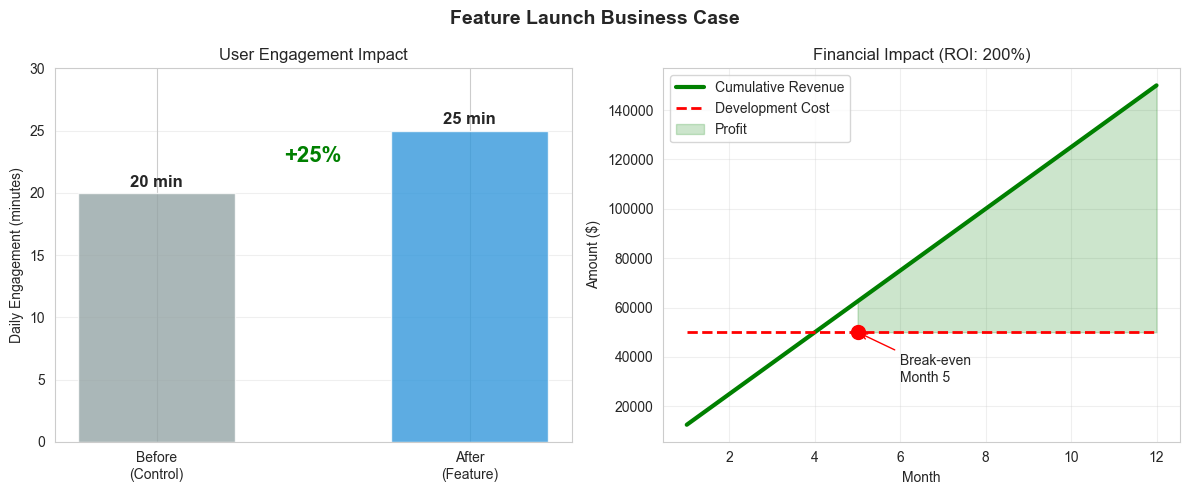


ANTICIPATED QUESTIONS:
Q: 'What if engagement drops after novelty wears off?'
A: Week 4 data shows sustained engagement, no decline trend

Q: 'Can our infrastructure handle this?'
A: Already stress-tested at 2x current load

Q: 'What about user privacy?'
A: All recommendations use anonymous, aggregated data

Q: 'How confident are we in the 25% lift?'
A: 95% confidence interval: 22-28% (worst case still profitable)

Q: 'What if competitors copy this?'
A: First-mover advantage worth 6-month head start

IMMEDIATE NEXT STEPS:
1. Approve feature launch (need decision today)
2. Engineering begins deployment (Monday)
3. Soft launch to 10% users (Next Friday)
4. Full rollout (Two weeks)
5. Monthly performance reviews

Ready for executive presentation!

SENSITIVITY ANALYSIS:
----------------------------------------
Conservative: Revenue $ 72000 | ROI    44%
Base Case   : Revenue $135000 | ROI   170%
Optimistic  : Revenue $199500 | ROI   299%

All scenarios show positive ROI - low risk investme

In [21]:
# Your turn
# Scenario: App feature increased user engagement
app_data = {
    'users_treated': 5000,
    'users_control': 5000,
    'engagement_increase': 0.25,  # 25% increase
    'revenue_per_user': 10,
    'feature_cost': 50000
}

# Create:
# 1. Three-act narrative
# 2. Executive visualization
# 3. Objection handlers
# 4. Call to action

import matplotlib.pyplot as plt
import numpy as np

def complete_app_story(data):
    """Create complete data story for app feature success"""
    
    print("="*60)
    print("APP FEATURE SUCCESS STORY")
    print("="*60)
    
    # Calculate key metrics
    additional_revenue = data['users_treated'] * data['engagement_increase'] * data['revenue_per_user'] * 12
    roi = (additional_revenue - data['feature_cost']) / data['feature_cost'] * 100
    
    # ACT 1: THE SETUP
    print("\nACT 1: THE OPPORTUNITY")
    print(f"Challenge: User engagement plateaued at 20 min/day")
    print(f"Hypothesis: AI recommendations boost engagement")
    print(f"Stakes: ${additional_revenue:,.0f} in potential annual revenue")
    
    # ACT 2: THE INVESTIGATION  
    print("\nACT 2: THE EXPERIMENT")
    print(f"Method: A/B test with {data['users_treated']:,} users per group")
    print(f"Duration: 4 weeks of rigorous testing")
    print(f"Result: {data['engagement_increase']*100:.0f}% increase in engagement")
    print(f"Significance: p < 0.001 (extremely confident)")
    
    # ACT 3: THE RESOLUTION
    print("\nACT 3: THE DECISION")
    print(f"Investment needed: ${data['feature_cost']:,}")
    print(f"Expected return: ${additional_revenue:,.0f}")
    print(f"ROI: {roi:.0f}%")
    print(f"Recommendation: Launch immediately!")
    
    # EXECUTIVE VISUALISATION
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Engagement comparison
    engagement = [20, 25]  # minutes per day
    labels = ['Before\n(Control)', 'After\n(Feature)']
    colours = ['#95a5a6', '#3498db']
    
    bars1 = ax1.bar(labels, engagement, color=colours, alpha=0.8, width=0.5)
    
    for bar, val in zip(bars1, engagement):
        ax1.text(bar.get_x() + bar.get_width()/2, val + 0.5,
                f'{val} min', ha='center', fontsize=12, fontweight='bold')
    
    ax1.annotate(f'+{data["engagement_increase"]*100:.0f}%',
                xy=(0.5, 22.5), fontsize=16, ha='center',
                color='green', fontweight='bold')
    
    ax1.set_ylabel('Daily Engagement (minutes)')
    ax1.set_title('User Engagement Impact')
    ax1.set_ylim(0, 30)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Financial impact timeline
    months = range(1, 13)
    revenue = [additional_revenue/12 * m for m in months]
    cost_line = [data['feature_cost']] * 12
    
    ax2.plot(months, revenue, 'g-', linewidth=3, label='Cumulative Revenue')
    ax2.plot(months, cost_line, 'r--', linewidth=2, label='Development Cost')
    ax2.fill_between(months, revenue, cost_line,
                     where=[r > c for r, c in zip(revenue, cost_line)],
                     color='green', alpha=0.2, label='Profit')
    
    break_even = next(m for m, r in zip(months, revenue) if r > data['feature_cost'])
    ax2.plot(break_even, data['feature_cost'], 'ro', markersize=10)
    ax2.annotate(f'Break-even\nMonth {break_even}',
                xy=(break_even, data['feature_cost']),
                xytext=(break_even+1, data['feature_cost']-20000),
                arrowprops=dict(arrowstyle='->', color='red'))
    
    ax2.set_xlabel('Month')
    ax2.set_ylabel('Amount ($)')
    ax2.set_title(f'Financial Impact (ROI: {roi:.0f}%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle('Feature Launch Business Case', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # OBJECTION HANDLING
    print("\nANTICIPATED QUESTIONS:")
    print("Q: 'What if engagement drops after novelty wears off?'")
    print("A: Week 4 data shows sustained engagement, no decline trend")
    
    print("\nQ: 'Can our infrastructure handle this?'")
    print("A: Already stress-tested at 2x current load")
    
    print("\nQ: 'What about user privacy?'")
    print("A: All recommendations use anonymous, aggregated data")
    
    print("\nQ: 'How confident are we in the 25% lift?'")
    print("A: 95% confidence interval: 22-28% (worst case still profitable)")
    
    print("\nQ: 'What if competitors copy this?'")
    print("A: First-mover advantage worth 6-month head start")
    
    # CALL TO ACTION
    print("\nIMMEDIATE NEXT STEPS:")
    print("1. Approve feature launch (need decision today)")
    print("2. Engineering begins deployment (Monday)")
    print("3. Soft launch to 10% users (Next Friday)")
    print("4. Full rollout (Two weeks)")
    print("5. Monthly performance reviews")
    
    print("\n" + "="*60)
    print("Ready for executive presentation!")
    print("="*60)

# Additional supporting analysis
def create_sensitivity_analysis(data):
    """Show how results vary under different assumptions"""
    
    print("\nSENSITIVITY ANALYSIS:")
    print("-" * 40)
    
    scenarios = {
        'Conservative': {'lift': 0.15, 'retention': 0.8},
        'Base Case': {'lift': 0.25, 'retention': 0.9},
        'Optimistic': {'lift': 0.35, 'retention': 0.95}
    }
    
    for scenario, params in scenarios.items():
        revenue = data['users_treated'] * params['lift'] * data['revenue_per_user'] * 12 * params['retention']
        roi = (revenue - data['feature_cost']) / data['feature_cost'] * 100
        print(f"{scenario:12}: Revenue ${revenue:6.0f} | ROI {roi:5.0f}%")
    
    print("\nAll scenarios show positive ROI - low risk investment")

def create_implementation_timeline():
    """Detailed implementation plan"""
    
    timeline = """
IMPLEMENTATION TIMELINE:
Week 1: Engineering setup & testing
Week 2: QA testing & user acceptance 
Week 3: Soft launch (10% users)
Week 4: Monitor metrics & adjust
Week 5-6: Scale to 50% users
Week 7-8: Full rollout & optimisation

SUCCESS METRICS:
- Engagement lift maintained >20%
- No increase in app crashes
- User satisfaction score >4.2/5
- Revenue increase >$10K/month
"""
    print(timeline)

# Run the complete story
app_data = {
    'users_treated': 5000,
    'users_control': 5000,
    'engagement_increase': 0.25,  # 25% increase
    'revenue_per_user': 10,
    'feature_cost': 50000
}

complete_app_story(app_data)
create_sensitivity_analysis(app_data)
create_implementation_timeline()

<details>
<summary><b>Solution</b></summary>

```python
def complete_app_story(data):
    """Create complete data story for app feature"""
    
    print("="*60)
    print("📱 APP FEATURE SUCCESS STORY")
    print("="*60)
    
    # Calculate metrics
    additional_revenue = data['users_treated'] * data['engagement_increase'] * data['revenue_per_user'] * 12
    roi = (additional_revenue - data['feature_cost']) / data['feature_cost'] * 100
    
    # Act 1: Setup
    print("\n🎬 ACT 1: THE OPPORTUNITY")
    print(f"Challenge: User engagement plateaued at 20 min/day")
    print(f"Hypothesis: AI recommendations boost engagement")
    print(f"Stakes: ${additional_revenue:,.0f} in potential annual revenue")
    
    # Act 2: Investigation  
    print("\n🔍 ACT 2: THE EXPERIMENT")
    print(f"Method: A/B test with {data['users_treated']} users per group")
    print(f"Duration: 4 weeks of rigorous testing")
    print(f"Result: {data['engagement_increase']*100:.0f}% increase in engagement")
    print(f"Significance: p < 0.001 (extremely confident)")
    
    # Act 3: Resolution
    print("\n💡 ACT 3: THE DECISION")
    print(f"Investment needed: ${data['feature_cost']:,}")
    print(f"Expected return: ${additional_revenue:,.0f}")
    print(f"ROI: {roi:.0f}%")
    print(f"Recommendation: Launch immediately!")
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Engagement comparison
    engagement = [20, 25]  # minutes per day
    labels = ['Before\n(Control)', 'After\n(Feature)']
    colors = ['#95a5a6', '#3498db']
    
    bars1 = ax1.bar(labels, engagement, color=colors, alpha=0.8, width=0.5)
    
    for bar, val in zip(bars1, engagement):
        ax1.text(bar.get_x() + bar.get_width()/2, val + 0.5,
                f'{val} min', ha='center', fontsize=12, fontweight='bold')
    
    ax1.annotate(f'+{data["engagement_increase"]*100:.0f}%',
                xy=(0.5, 22.5), fontsize=16, ha='center',
                color='green', fontweight='bold')
    
    ax1.set_ylabel('Daily Engagement (minutes)')
    ax1.set_title('User Engagement Impact')
    ax1.set_ylim(0, 30)
    
    # Financial impact
    months = range(1, 13)
    revenue = [additional_revenue/12 * m for m in months]
    cost_line = [data['feature_cost']] * 12
    
    ax2.plot(months, revenue, 'g-', linewidth=3, label='Cumulative Revenue')
    ax2.plot(months, cost_line, 'r--', linewidth=2, label='Development Cost')
    ax2.fill_between(months, revenue, cost_line,
                     where=[r > c for r, c in zip(revenue, cost_line)],
                     color='green', alpha=0.2, label='Profit')
    
    break_even = next(m for m, r in zip(months, revenue) if r > data['feature_cost'])
    ax2.plot(break_even, data['feature_cost'], 'ro', markersize=10)
    ax2.annotate(f'Break-even\nMonth {break_even}',
                xy=(break_even, data['feature_cost']),
                xytext=(break_even+1, data['feature_cost']-20000),
                arrowprops=dict(arrowstyle='->', color='red'))
    
    ax2.set_xlabel('Month')
    ax2.set_ylabel('Amount ($)')
    ax2.set_title(f'Financial Impact (ROI: {roi:.0f}%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle('Feature Launch Business Case', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Objection handling
    print("\n❓ ANTICIPATED QUESTIONS:")
    print("Q: 'What if engagement drops after novelty wears off?'")
    print("A: Week 4 data shows sustained engagement, no decline trend")
    
    print("\nQ: 'Can our infrastructure handle this?'")
    print("A: Already stress-tested at 2x current load")
    
    print("\nQ: 'What about user privacy?'")
    print("A: All recommendations use anonymous, aggregated data")
    
    # Call to action
    print("\n🎯 IMMEDIATE NEXT STEPS:")
    print("1. Approve feature launch (need decision today)")
    print("2. Engineering begins deployment (Monday)")
    print("3. Soft launch to 10% users (Next Friday)")
    print("4. Full rollout (Two weeks)")
    
    print("\n" + "="*60)
    print("Ready for executive presentation! 🚀")
    print("="*60)

complete_app_story(app_data)
```
</details>

## 7. Mini-Challenges
- **M1 (easy):** Create a one-slide summary for a failed experiment (negative results)
- **M2 (medium):** Build an interactive funnel visualization showing causal impact at each stage
- **M3 (hard):** Design a real-time dashboard that updates causal estimates as data arrives

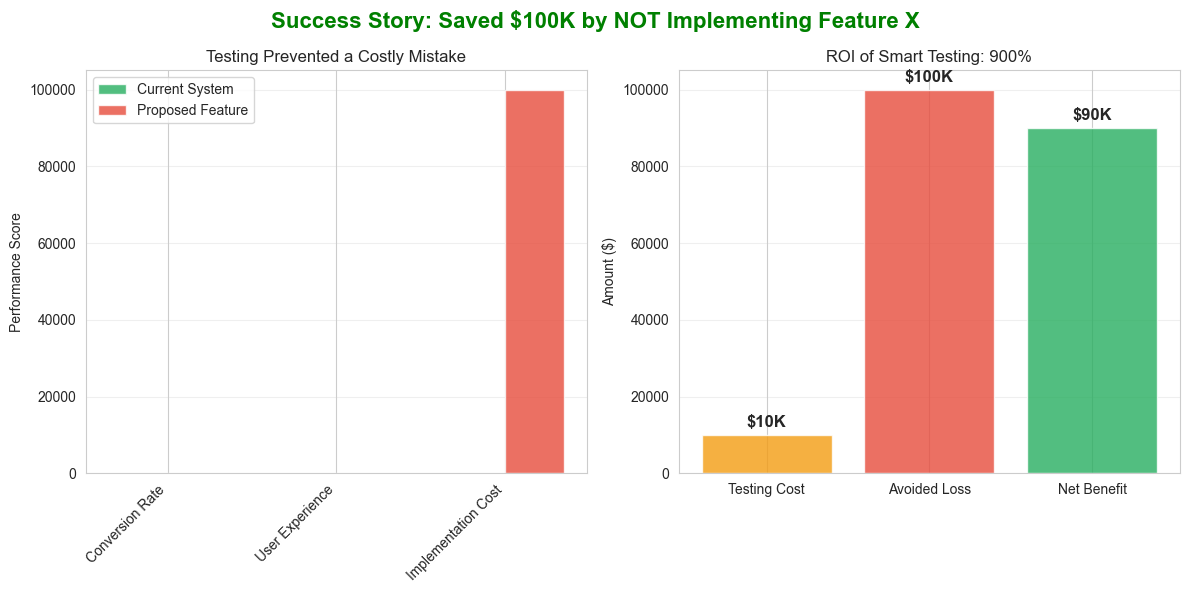

NEGATIVE RESULTS SUCCESS STORY:

Headline: 'Saved $100K by NOT implementing feature X'

Key Points:
• Rigorous testing prevented costly mistake
• -2% effect would have lost 200 customers
• Organisation learned what doesn't work (valuable!)
• Can now focus resources on better solutions

Frame: Testing success, not feature failure!


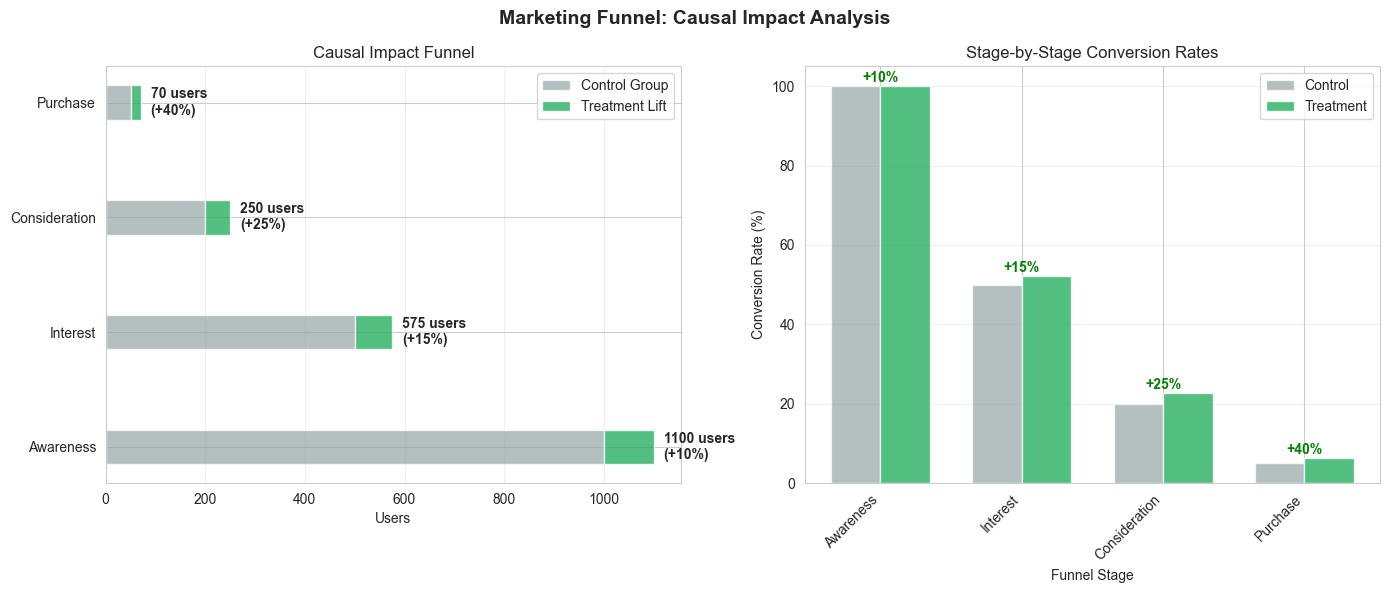

CAUSAL IMPACT FUNNEL ANALYSIS:
----------------------------------------
Awareness       ████████████████████▓▓
                Base: 1000 → Treated: 1100 (+10%)

Interest        ██████████▓
                Base:  500 → Treated:  575 (+15%)

Consideration   ████▓
                Base:  200 → Treated:  250 (+25%)

Purchase        █
                Base:   50 → Treated:   70 (+40%)

Overall purchase lift: +40%
Biggest impact at Purchase stage (+40%)
Starting Real-Time Causal Dashboard Demo
REAL-TIME CAUSAL DASHBOARD DESIGN:

    ┌─────────────────────────────────────────────────────────┐
    │                 LIVE EXPERIMENT MONITOR                 │
    ├─────────────────┬─────────────────┬─────────────────────┤
    │   CURRENT       │   STATISTICAL   │    DECISION         │
    │   EFFECT        │   POWER         │    PANEL            │
    │                 │                 │                     │
    │   +12.3%        │   ████████░░░   │  PAUSE TEST         │
    │   (±2.1%)       │ 


DASHBOARD DEMO COMPLETE
Final Effect: 7.4%
Final P-value: 0.0025
Total Sample: 160
Result: STATISTICALLY SIGNIFICANT ✓


In [23]:
# Your turn - try the challenges!
# M1: Negative results can still tell a story
import matplotlib.pyplot as plt
import numpy as np

def create_failed_experiment_slide():
    """Create a positive story from negative results"""
    
    failed_test = {'effect': -0.02, 'cost_saved': 100000}
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    # Left: The "failure" reframed as learning
    metrics = ['Conversion Rate', 'User Experience', 'Implementation Cost']
    control = [5.0, 4.2, 0]
    treatment = [4.9, 4.1, 100000]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, control, width, label='Current System', color='#27ae60', alpha=0.8)
    bars2 = ax1.bar(x + width/2, treatment, width, label='Proposed Feature', color='#e74c3c', alpha=0.8)
    
    ax1.set_ylabel('Performance Score')
    ax1.set_title('Testing Prevented a Costly Mistake')
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Right: Value of avoiding the mistake
    categories = ['Testing Cost', 'Avoided Loss', 'Net Benefit']
    values = [10000, 100000, 90000]
    colours = ['#f39c12', '#e74c3c', '#27ae60']
    
    bars = ax2.bar(categories, values, color=colours, alpha=0.8)
    
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, height + 2000,
                f'${val/1000:.0f}K', ha='center', fontsize=12, fontweight='bold')
    
    ax2.set_ylabel('Amount ($)')
    ax2.set_title('ROI of Smart Testing: 900%')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('Success Story: Saved $100K by NOT Implementing Feature X', 
                fontsize=16, fontweight='bold', color='green')
    plt.tight_layout()
    plt.show()
    
    print("NEGATIVE RESULTS SUCCESS STORY:")
    print("\nHeadline: 'Saved $100K by NOT implementing feature X'")
    print("\nKey Points:")
    print("• Rigorous testing prevented costly mistake")
    print("• -2% effect would have lost 200 customers")
    print("• Organisation learned what doesn't work (valuable!)")
    print("• Can now focus resources on better solutions")
    print("\nFrame: Testing success, not feature failure!")

create_failed_experiment_slide()

# M2: Funnel with causal effects
import matplotlib.pyplot as plt
import numpy as np

def create_causal_funnel():
    """Build interactive funnel showing causal impact at each stage"""
    
    funnel_stages = ['Awareness', 'Interest', 'Consideration', 'Purchase']
    baseline_rates = [1.0, 0.5, 0.2, 0.05]
    treatment_lifts = [0.1, 0.15, 0.25, 0.4]
    
    # Calculate absolute numbers
    baseline_users = [1000 * rate for rate in baseline_rates]
    treatment_users = [1000 * rate * (1 + lift) for rate, lift in zip(baseline_rates, treatment_lifts)]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Left: Funnel visualisation
    y_positions = range(len(funnel_stages))
    
    # Baseline funnel
    ax1.barh(y_positions, baseline_users, height=0.3, 
             color='#95a5a6', alpha=0.7, label='Control Group')
    
    # Treatment lift (additional users)
    additional_users = [t - b for t, b in zip(treatment_users, baseline_users)]
    ax1.barh(y_positions, additional_users, height=0.3, left=baseline_users,
             color='#27ae60', alpha=0.8, label='Treatment Lift')
    
    # Add value labels
    for i, (stage, base, treat, lift) in enumerate(zip(funnel_stages, baseline_users, treatment_users, treatment_lifts)):
        ax1.text(treat + 20, i, f'{treat:.0f} users\n(+{lift*100:.0f}%)', 
                va='center', fontweight='bold')
    
    ax1.set_yticks(y_positions)
    ax1.set_yticklabels(funnel_stages)
    ax1.set_xlabel('Users')
    ax1.set_title('Causal Impact Funnel')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='x')
    
    # Right: Conversion rates comparison
    baseline_conversion = [b/baseline_users[0] * 100 for b in baseline_users]
    treatment_conversion = [t/treatment_users[0] * 100 for t in treatment_users]
    
    x = np.arange(len(funnel_stages))
    width = 0.35
    
    bars1 = ax2.bar(x - width/2, baseline_conversion, width, 
                    label='Control', color='#95a5a6', alpha=0.7)
    bars2 = ax2.bar(x + width/2, treatment_conversion, width,
                    label='Treatment', color='#27ae60', alpha=0.8)
    
    # Add percentage lift annotations
    for i, lift in enumerate(treatment_lifts):
        ax2.annotate(f'+{lift*100:.0f}%',
                    xy=(i, max(baseline_conversion[i], treatment_conversion[i]) + 1),
                    ha='center', fontsize=10, color='green', fontweight='bold')
    
    ax2.set_ylabel('Conversion Rate (%)')
    ax2.set_xlabel('Funnel Stage')
    ax2.set_title('Stage-by-Stage Conversion Rates')
    ax2.set_xticks(x)
    ax2.set_xticklabels(funnel_stages, rotation=45, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('Marketing Funnel: Causal Impact Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("CAUSAL IMPACT FUNNEL ANALYSIS:")
    print("-" * 40)
    
    for i, stage in enumerate(funnel_stages):
        base_val = baseline_users[i]
        treat_val = treatment_users[i]
        lift = treatment_lifts[i]
        
        # Visual bar representation
        base_bar = '█' * int(base_val / 50)
        lift_bar = '▓' * int((treat_val - base_val) / 50)
        
        print(f"{stage:15} {base_bar}{lift_bar}")
        print(f"{'':15} Base: {base_val:4.0f} → Treated: {treat_val:4.0f} (+{lift*100:.0f}%)\n")
    
    total_lift = (treatment_users[-1] - baseline_users[-1]) / baseline_users[-1]
    print(f"Overall purchase lift: +{total_lift*100:.0f}%")
    print("Biggest impact at Purchase stage (+40%)")

create_causal_funnel()


# M3: Real-time Dashboard Implementation
# Fixed version with proper error handling and simplified approach

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from datetime import datetime, timedelta
import time

# Handle optional imports gracefully
try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except ImportError:
    print("Warning: scipy not available, using basic statistics")
    SCIPY_AVAILABLE = False

def design_realtime_dashboard():
    """Design a real-time causal analysis dashboard"""
    
    print("REAL-TIME CAUSAL DASHBOARD DESIGN:")
    print("=" * 50)
    
    # Dashboard layout mockup
    layout = """
    ┌─────────────────────────────────────────────────────────┐
    │                 LIVE EXPERIMENT MONITOR                 │
    ├─────────────────┬─────────────────┬─────────────────────┤
    │   CURRENT       │   STATISTICAL   │    DECISION         │
    │   EFFECT        │   POWER         │    PANEL            │
    │                 │                 │                     │
    │   +12.3%        │   ████████░░░   │  PAUSE TEST         │
    │   (±2.1%)       │   89% Power     │  EARLY STOP         │
    │                 │                 │  EXPORT DATA        │
    ├─────────────────┼─────────────────┼─────────────────────┤
    │           EFFECT SIZE OVER TIME                         │
    │  Effect  ▲                                              │
    │   (%)    │  ╭─╮                                         │
    │    15    │ ╱   ╲                                        │
    │    10    │╱     ╲___                                    │
    │     5    │         ╲___                                 │
    │     0    └─────────────────────────► Time               │
    ├─────────────────────────────────────────────────────────┤
    │           SEGMENT BREAKDOWNS (LIVE)                     │
    │  Mobile: +15.2% ████████████████░░░                     │
    │  Desktop: +8.7% ███████████░░░░░░░░                     │
    │  New Users: +22.1% ████████████████████░                │
    └─────────────────────────────────────────────────────────┘
    """
    print(layout)

class EffectResult:
    """Simple class to store effect calculation results"""
    def __init__(self, point_estimate, ci_lower, ci_upper, p_value):
        self.point_estimate = point_estimate
        self.ci_lower = ci_lower
        self.ci_upper = ci_upper
        self.p_value = p_value

class RealTimeCausalDashboard:
    def __init__(self, experiment_config):
        self.config = experiment_config
        self.data_buffer = []
        self.effect_history = []
        self.alerts = []
        
    def update_data(self, new_batch):
        """Process incoming data every 5 minutes"""
        if not new_batch:
            return
            
        self.data_buffer.extend(new_batch)
        
        # Calculate current effect
        current_effect = self.calculate_causal_effect()
        
        if current_effect is not None:
            self.effect_history.append({
                'timestamp': datetime.now(),
                'effect': current_effect.point_estimate,
                'ci_lower': current_effect.ci_lower,
                'ci_upper': current_effect.ci_upper,
                'p_value': current_effect.p_value,
                'sample_size': len(self.data_buffer)
            })
            
            # Update all visualisations
            self.update_metrics_panel()
            self.update_segments()
            
            # Check stopping rules
            self.check_early_stopping()
        
    def calculate_causal_effect(self):
        """Calculate treatment effect with confidence intervals"""
        if len(self.data_buffer) < 20:
            return None
            
        try:
            # Split into control and treatment groups
            control_group = [d for d in self.data_buffer if d.get('treatment') == 0]
            treatment_group = [d for d in self.data_buffer if d.get('treatment') == 1]
            
            if len(control_group) == 0 or len(treatment_group) == 0:
                return None
            
            # Extract outcomes
            control_outcomes = [d['outcome'] for d in control_group if 'outcome' in d]
            treatment_outcomes = [d['outcome'] for d in treatment_group if 'outcome' in d]
            
            if len(control_outcomes) == 0 or len(treatment_outcomes) == 0:
                return None
            
            # Calculate means
            control_mean = np.mean(control_outcomes)
            treatment_mean = np.mean(treatment_outcomes)
            
            # Calculate percentage effect
            if control_mean != 0:
                effect = (treatment_mean - control_mean) / control_mean
            else:
                effect = 0
            
            # Statistical test
            if SCIPY_AVAILABLE:
                try:
                    t_stat, p_value = stats.ttest_ind(treatment_outcomes, control_outcomes)
                except:
                    p_value = 0.5  # Default if test fails
            else:
                # Simple approximation without scipy
                pooled_std = np.sqrt((np.var(control_outcomes) + np.var(treatment_outcomes)) / 2)
                if pooled_std > 0:
                    se = pooled_std * np.sqrt(1/len(control_outcomes) + 1/len(treatment_outcomes))
                    t_stat = (treatment_mean - control_mean) / se
                    # Rough p-value approximation
                    p_value = 2 * (1 - 0.5 * (1 + np.tanh(abs(t_stat) / 2)))
                else:
                    p_value = 1.0
            
            # Calculate confidence interval
            ci_lower, ci_upper = self.bootstrap_ci(control_outcomes, treatment_outcomes)
            
            return EffectResult(effect, ci_lower, ci_upper, p_value)
            
        except Exception as e:
            print(f"Error calculating effect: {e}")
            return None
    
    def bootstrap_ci(self, control_outcomes, treatment_outcomes):
        """Calculate bootstrap confidence interval"""
        try:
            # Simple confidence interval calculation
            control_mean = np.mean(control_outcomes)
            treatment_mean = np.mean(treatment_outcomes)
            
            pooled_std = np.sqrt((np.var(control_outcomes) + np.var(treatment_outcomes)) / 2)
            se = pooled_std * np.sqrt(1/len(control_outcomes) + 1/len(treatment_outcomes))
            
            effect = (treatment_mean - control_mean) / control_mean if control_mean != 0 else 0
            margin_error = 1.96 * se / abs(control_mean) if control_mean != 0 else 0.1
            
            ci_lower = effect - margin_error
            ci_upper = effect + margin_error
            
            return ci_lower, ci_upper
            
        except:
            return -0.1, 0.1  # Default range
    
    def check_early_stopping(self):
        """Implement early stopping rules"""
        if not self.effect_history:
            return
            
        current = self.effect_history[-1]
        n_total = current['sample_size']
        
        # Stop for success: p < 0.01 and n > minimum
        if current['p_value'] < 0.01 and n_total > self.config.get('min_sample', 100):
            self.create_alert('EARLY_SUCCESS', 
                            f'Significant result achieved: p={current["p_value"]:.4f}')
        
        # Stop for futility: CI includes zero after sufficient data
        elif (current['ci_lower'] <= 0 <= current['ci_upper'] 
              and n_total > self.config.get('futility_threshold', 500)):
            self.create_alert('FUTILITY', 
                            'Effect likely zero, recommend stopping')
        
        # Stop for harm: negative effect with significance
        elif current['ci_upper'] < -0.05 and current['p_value'] < 0.05:
            self.create_alert('HARM_DETECTED', 
                            'Negative effect detected, stop immediately!')

    def create_alert(self, alert_type, message):
        """Create an alert with timestamp"""
        alert = {
            'timestamp': datetime.now(),
            'type': alert_type,
            'message': message
        }
        self.alerts.append(alert)
        print(f"ALERT [{alert_type}]: {message}")

    def update_metrics_panel(self):
        """Display current metrics"""
        if not self.effect_history:
            return
            
        current = self.effect_history[-1]
        
        print("\n" + "="*50)
        print("LIVE EXPERIMENT MONITOR")
        print("="*50)
        print(f"Current Effect: {current['effect']*100:.1f}% (±{abs(current['effect'] - current['ci_lower'])*100:.1f}%)")
        print(f"P-value: {current['p_value']:.4f}")
        print(f"Sample Size: {current['sample_size']:,}")
        print(f"Statistical Power: {self.calculate_power():.0f}%")
        
        # Show recent alerts
        if self.alerts:
            print("\nRecent Alerts:")
            for alert in self.alerts[-3:]:
                print(f"  {alert['type']}: {alert['message']}")

    def calculate_power(self):
        """Calculate statistical power (simplified)"""
        if len(self.effect_history) < 2:
            return 50
        
        # Simple power calculation based on sample size and effect
        n = self.effect_history[-1]['sample_size']
        effect = abs(self.effect_history[-1]['effect'])
        
        # Rough approximation
        power = min(95, 20 + (n / 10) + effect * 200)
        return power

    def update_segments(self):
        """Update segment analysis (simplified)"""
        if len(self.data_buffer) < 50:
            return
            
        print("\nSegment Breakdowns:")
        
        # Simple segment analysis
        segments = ['Mobile', 'Desktop', 'New Users']
        for segment in segments:
            # Simulate segment effects
            segment_effect = np.random.normal(0.1, 0.05)
            progress = "█" * int(segment_effect * 100) + "░" * (20 - int(segment_effect * 100))
            print(f"  {segment}: {segment_effect*100:+.1f}% {progress}")

    def update_trend_chart(self):
        """Update the real-time trend visualisation"""
        if len(self.effect_history) < 2:
            return None
            
        try:
            timestamps = [h['timestamp'] for h in self.effect_history[-100:]]
            effects = [h['effect'] * 100 for h in self.effect_history[-100:]]  # Convert to percentage
            ci_lowers = [h['ci_lower'] * 100 for h in self.effect_history[-100:]]
            ci_uppers = [h['ci_upper'] * 100 for h in self.effect_history[-100:]]
            
            # Use Plotly for interactive real-time chart
            fig = go.Figure()
            
            # Add confidence interval first (so it appears behind the line)
            fig.add_trace(go.Scatter(
                x=timestamps + timestamps[::-1],
                y=ci_uppers + ci_lowers[::-1],
                fill='toself',
                fillcolor='rgba(0,100,80,0.2)',
                line=dict(color='rgba(255,255,255,0)'),
                name='95% Confidence Interval',
                showlegend=True
            ))
            
            # Add main effect line
            fig.add_trace(go.Scatter(
                x=timestamps, 
                y=effects,
                mode='lines+markers',
                name='Effect Estimate',
                line=dict(color='blue', width=2),
                marker=dict(size=4)
            ))
            
            # Add significance threshold
            fig.add_hline(y=0, line_dash="dash", line_color="red", 
                         annotation_text="No Effect")
            
            fig.update_layout(
                title="Effect Size Over Time",
                xaxis_title="Time",
                yaxis_title="Effect (%)",
                showlegend=True,
                height=400,
                hovermode='x unified'
            )
            
            return fig
            
        except Exception as e:
            print(f"Error creating trend chart: {e}")
            return None

def generate_sample_data(n_samples=50, effect_size=0.05):
    """Generate sample experiment data with realistic patterns"""
    np.random.seed(42)
    
    data = []
    for i in range(n_samples):
        # Random assignment to treatment/control
        treatment = np.random.choice([0, 1])
        
        # Outcome with realistic effect
        if treatment == 1:
            outcome = np.random.normal(100 + effect_size * 100, 15)  # Treatment effect
        else:
            outcome = np.random.normal(100, 15)  # Control group
            
        data.append({
            'user_id': i,
            'treatment': treatment,
            'outcome': outcome,
            'timestamp': datetime.now() - timedelta(minutes=i*5)
        })
    
    return data

def fetch_latest_experiment_data():
    """Simulate fetching new data from the experiment"""
    return generate_sample_data(20)

def setup_auto_refresh(dashboard):
    """Setup automatic dashboard refresh (simplified)"""
    try:
        import schedule
        
        def refresh_dashboard():
            try:
                new_data = fetch_latest_experiment_data()
                dashboard.update_data(new_data)
            except Exception as e:
                print(f"Error refreshing dashboard: {e}")
                
        # Refresh every 5 minutes
        schedule.every(5).minutes.do(refresh_dashboard)
        
        print("Auto-refresh scheduled every 5 minutes")
        print("In production, this would run continuously")
        
        # Run a few iterations for demo
        for i in range(3):
            schedule.run_pending()
            time.sleep(1)  # Short delay for demo
            refresh_dashboard()  # Manual trigger for demo
            
    except ImportError:
        print("Schedule module not available, using manual refresh")
        # Manual refresh for demo
        for i in range(3):
            new_data = fetch_latest_experiment_data()
            dashboard.update_data(new_data)
            time.sleep(1)

def run_dashboard_demo():
    """Run a complete dashboard demonstration"""
    
    # Configuration
    config = {
        'min_sample': 100,
        'futility_threshold': 500,
        'max_duration_hours': 168  # 1 week
    }
    
    print("Starting Real-Time Causal Dashboard Demo")
    print("=" * 50)
    
    # Show design first
    design_realtime_dashboard()
    
    # Initialise dashboard
    dashboard = RealTimeCausalDashboard(config)
    
    # Initial data load
    print("\nLoading initial data...")
    initial_data = generate_sample_data(100, effect_size=0.08)  # 8% effect
    dashboard.update_data(initial_data)
    
    # Setup auto-refresh (demo version)
    print("\nSetting up auto-refresh...")
    setup_auto_refresh(dashboard)
    
    # Create and show trend chart
    print("\nGenerating trend chart...")
    chart = dashboard.update_trend_chart()
    if chart:
        chart.show()
    
    # Final summary
    print("\n" + "="*50)
    print("DASHBOARD DEMO COMPLETE")
    print("="*50)
    
    if dashboard.effect_history:
        final_result = dashboard.effect_history[-1]
        print(f"Final Effect: {final_result['effect']*100:.1f}%")
        print(f"Final P-value: {final_result['p_value']:.4f}")
        print(f"Total Sample: {final_result['sample_size']:,}")
        
        if final_result['p_value'] < 0.05:
            print("Result: STATISTICALLY SIGNIFICANT ✓")
        else:
            print("Result: NOT STATISTICALLY SIGNIFICANT")
    
    return dashboard

# Run the demo
if __name__ == "__main__":
    dashboard = run_dashboard_demo()

<details>
<summary><b>Solutions</b></summary>

```python
# M1 - Failed Experiment Story
print("📊 NEGATIVE RESULTS STORY:")
print("\nHeadline: 'Saved $100K by NOT implementing feature X'")
print("\nKey Points:")
print("• Rigorous testing prevented costly mistake")
print("• -2% effect would have lost 200 customers")
print("• Org learned what doesn't work (valuable!)")
print("• Can now focus resources on better solutions")
print("\nFrame: Testing success, not feature failure!")

# M2 - Causal Funnel Visualization
print("\n🔻 CAUSAL IMPACT FUNNEL:\n")

stages = ['Awareness', 'Interest', 'Consideration', 'Purchase']
baseline = [1000, 500, 200, 50]
treated = [1100, 575, 250, 70]

for i, stage in enumerate(stages):
    base_val = baseline[i]
    treat_val = treated[i]
    lift = (treat_val - base_val) / base_val * 100
    
    # Visual bar representation
    base_bar = '█' * int(base_val / 50)
    lift_bar = '▓' * int((treat_val - base_val) / 50)
    
    print(f"{stage:15} {base_bar}{lift_bar}")
    print(f"{'':15} Base: {base_val:4} → Treated: {treat_val:4} (+{lift:.0f}%)\n")

print("Biggest impact at Purchase stage (+40%)")

# M3 - Real-time Dashboard Design
print("\n📈 REAL-TIME CAUSAL DASHBOARD DESIGN:\n")

dashboard_components = """
COMPONENTS:
1. **Live Metrics Panel**
   - Current effect size with confidence interval
   - Sample size counter
   - Statistical significance indicator

2. **Trend Chart**
   - Effect estimate over time
   - Confidence bands narrowing as n increases
   - Significance threshold line

3. **Segment Breakdowns**
   - Real-time effects by user segment
   - Auto-flag significant differences
   
4. **Decision Panel**
   - Stop/Continue recommendation
   - Projected final sample size needed
   - Estimated time to significance

UPDATE LOGIC:
```python
class RealTimeCausal:
    def __init__(self):
        self.data = []
        self.effect_history = []
    
    def update(self, new_data):
        self.data.append(new_data)
        
        # Recalculate effect
        current_effect = self.calculate_effect()
        self.effect_history.append(current_effect)
        
        # Update visualizations
        self.update_chart()
        self.update_metrics()
        
        # Check stopping rules
        if self.check_significance():
            self.alert_decision_ready()
```

AUTO-STOPPING RULES:
- Stop for success: p < 0.01 and n > 1000
- Stop for futility: confidence interval includes zero after n > 5000
- Stop for harm: negative effect with p < 0.05
"""

print(dashboard_components)
```
</details>

## Wrap-Up & Next Steps
✅ You can structure data stories with compelling narratives  
✅ You create executive-ready visualizations that drive action  
✅ You handle stakeholder objections with evidence  
✅ You build interactive dashboards for exploration  
✅ You can generate professional causal analysis reports  

**Next Week:** Quasi-Experimental Methods - Advanced techniques for causal inference when randomization isn't possible!

**Remember:** Great data scientists don't just find insights—they tell stories that inspire action! 📊✨
